<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/pdp_ice_pfi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partial Dependency Function (PDF) with respect to a set of features $\mathbf{x}_F$, denoted as $f_F(\mathbf{x}_F)$
$$f_F(\mathbf{x}_F) = E_{\mathbf{x}_{-F}}\left[f\left(\mathbf{x}_F,\mathbf{x}_{-F}\right)\right]\approx \frac{1}{n}\sum_{i=1}^n f\left(\mathbf{x}_F,\mathbf{x}_{-F}^{(i)}\right)$$
$\mathbf{x}_{-F}$ is the rest of the features (other than $\mathbf{x}_F$) and $\mathbf{x}_{-F}^{(i)}$ denotes the values of $\mathbf{x}_{-F}$ features for the i-th datapoint.
$f$ is the actual predictive function whose behaviour we are trying to interpret.

The score (measure of influence of feature $F$ on the target) of the feature $F$ is something like the variance of the PDF.
$$ S_f(x_F) = \sqrt{\frac{1}{k-1}\sum_{i=1}^kf\left(\mathbf{x}_F^{(i)},\mathbf{x}_{-F}\right)-\frac{1}{k}\sum_{i=1}^kf\left(\mathbf{x}_F^{(i)},\mathbf{x}_{-F}\right)^2}$$
where $\mathbf{x}_F^{(i)}$ is the i-th unique value for $\mathbf{x}_F$ in the dataset.

In [1]:
import os
import pandas as pd
from pandas import DataFrame as DF
import numpy as np
from numpy import array as Array
from typing import Any, List, Tuple, Dict
from abc import ABC, abstractmethod
from collections import OrderedDict
import matplotlib.pyplot as plt
from itertools import combinations
import math


# from google.colab import drive
# drive.mount('/content/gdrive')
DATASETS_PATH = os.path.join(os.path.expanduser('~/Projects/UpgradDemos/Datasets'))
pd.options.display.float_format = '{:.5f}'.format
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [ ]:
from sklearn.model_selection import train_test_split

class PDPDataset:
    def __init__(self, dataset_name:str, drop_cols:List[str]=None, test_size:float=0.2):
        dataset_file = os.path.join(DATASETS_PATH, f'{dataset_name}.csv')
        self.dataset = pd.read_csv(dataset_file)
        print('Sample of the Raw Dataset')
        print(self.dataset.head())
        if drop_cols is not None:
            self.dataset.drop(columns=drop_cols, axis=1, inplace=True)
        print()
        print('Sample of the Cleaned Dataset')
        print(self.dataset.head())
        print(f'N Datapointss: {len(self.dataset)}, N Features: {len(self.dataset.columns)}')
        self.train_data, self.test_data = self.split_dataset(test_size=test_size)

    @property
    def n(self): return len(self.dataset)

    @property
    def dim(self):
        assert self.dataset.shape[1] == len(self.all_features)
        return (len(self.all_features) - 1)

    def size(self, subset:str=None): return self.data_subset(subset).shape[0]

    def split_dataset(self, test_size:float=0.2) -> Tuple[DF, DF]:
        return train_test_split(self.dataset, test_size=test_size)

    @property
    def all_features(self) -> List[str]: return list(self.dataset.columns)

    def data_subset(self, subset:str=None) -> DF:
        return (self.dataset if subset is None else (self.train_data if subset == 'train' else self.test_data))

    def data(self, features:List[str], subset:str=None) -> DF:
        subset_data = self.data_subset(subset)
        return subset_data[features]

    def features_array(self, subset:str=None, sample_size:int=None) -> Array:
        arr = self.data(self.all_features[:-1], subset).to_numpy()
        if sample_size is None:
            return arr
        else:
            samples = np.random.choice(np.arange(arr.shape[0]), size=sample_size, replace=False)
            return arr[samples]

    def target_array(self, subset:str=None) -> Array:
        return np.squeeze(self.data([self.all_features[-1]], subset).to_numpy())

    def unique_values(self, features:List[str]) -> List[List[Any]]:
        """Return the unique combinations of values of the features in the dataset."""
        assert set(features).issubset(set(self.all_features)), "Features must be a subset of dataset features."
        return np.squeeze(self.dataset[features].drop_duplicates().values).tolist()

    def partial_dependency_data(self, features:List[str], values:List[Any], subset:str=None, sample_size:int=None) -> Array:
        """Replace the values of the features with the given values for all the datapointsand return the resulting dataset."""
        subset_data = self.features_array(subset=subset, sample_size=sample_size)
        # Replacing all the values for each of the features with the corresponding value
        # This is the core of the Partial Dependency Plot --- averaging over all other features
        for f, v in zip(features, values):
            subset_data[:, self.all_features.index(f)] = v
        return subset_data

    def permute_feature_values(self, feature:str, subset:str=None, n_permutations:int=100) -> Array:
        subset_values = self.features_array(subset=subset)
        feature_idx = self.all_features.index(feature)
        feature_values = np.tile(subset_values[:, feature_idx][:, np.newaxis], (1, n_permutations))
        # Generate 'n_permutations' permutations of the feature values and stack them together and align the datapoint id axis
        rng = np.random.default_rng()
        permuted_values = rng.permuted(feature_values, axis=0)
        # Match the dimensions
        subset_values = np.tile(subset_values[:, np.newaxis, :], (1, (n_permutations+1), 1))

        # Replace the values of the feature with the permuted values --- leave the first along the permutation axis as the original
        subset_values[:, 1:, feature_idx] = permuted_values
        return subset_values

    def interpolated_data(self, datapoints:Array, feature:str, sample_size:int=100) -> Array:
        """Create 'sample_size" copies of the datapoints with values of 'feature' ranging from its max to min value"""
        if len(datapoints.shape) == 1:
            datapoints = datapoints[np.newaxis, :]
            # Get the mex and min value for the feature
        f_values = self.unique_values([feature])
        max_val, min_val = max(f_values), min(f_values)
        # Generate 'sample_size' interpolated values between max and min
        interpolated_f_values = np.linspace(min_val, max_val, sample_size)
        # Make copies of 'datapoints'
        ice_f_data = np.tile(datapoints[:, np.newaxis, :], (1, sample_size, 1))
        # Replace the 'feature' values by the interpolated values
        ice_f_data[:, :, self.all_features.index(feature)] = interpolated_f_values[np.newaxis, :]
        return interpolated_f_values, ice_f_data

In [ ]:
class PDPModel:
    def __init__(self, model):
        self.model = model

    def predict(self, datapoints:Array) -> Array:
        # Flatten the feature array into 2d array --- the feature dimension remains as is
        flat_size = math.prod(datapoints.shape[:-1])
        return self.model.predict(datapoints.reshape(flat_size, -1)).reshape(*datapoints.shape[:-1])

    def train_and_test(self, train_data:Array, train_target:Array, test_data:Array, test_target:Array):
        self.model.fit(train_data, train_target)
        return self.model.score(test_data, test_target)

    def mse(self, datapoints:Array, targets:Array):
        assert targets.ndim == 1, "Targets must be a 1d array"
        assert datapoints.shape[0] == targets.shape[0], "Features and targets must have the same number of datapoints"
        preds = self.predict(datapoints)
        if preds.ndim > 1:
            new_axes = tuple(np.arange(1, preds.ndim).tolist())
            targets = np.expand_dims(targets, axis=new_axes)
        # Compute the mean squared error across all datapoints
        return np.mean((preds - targets) ** 2, axis=0)

In [ ]:
plt.rcParams["figure.figsize"] = (15,10)

class PartialDependencyPlot:
    def __init__(self, dataset:PDPDataset, model:PDPModel):
        self.dataset = dataset
        self.model = model

    def plot(self, features:List[str], subset:str='train', sample_size:int=50,
             labels:List[str]=None, denorm_fns:List[Any]=None):
        # The values in the dataset are often normalized
        # The denorm_fns will be used to denormalize them and show the actual (human interpretable) values in the plot
        assert set(features).issubset(set(self.dataset.all_features)), "Features must be a subset of dataset features."
        labels = labels if labels is not None else features
        denorm_fns = denorm_fns if denorm_fns is not None else [None] * len(features)
        assert len(features) == len(labels) == len(denorm_fns)

        # +1 for the Bar chart with feature scores
        plot_size = int(math.ceil(math.sqrt(len(features) + 1)))
        # fig, axes = plt.subplots(plot_size, plot_size, figsize=(20, 5))
        f_scores = []
        # Generate the PDP plot for each of the features given
        for i, (f, label, denorm_fn) in enumerate(zip(features, labels, denorm_fns)):
            # Get the unique values for the feature
            f_values = self.dataset.unique_values([f])
            pdp_series = []
            # Get the prediction averages over all other features for this given value of feature 'f'
            for f_value in f_values:
                # Get the data with the 'f' value replaced by 'f_value' for all the rows
                feature_array = self.dataset.partial_dependency_data([f], [f_value], subset=subset, sample_size=sample_size)
                # Average the predictions for the modified dataset
                pred = np.mean(self.model.predict(feature_array))
                # Add the value of the feature and the average prediction to the series
                pdp_series.append((denorm_fn(f_value) if denorm_fn is not None else f_value, pred))
            f_val_series, pred_series = zip(*pdp_series)
            f_scores.append(np.std(pred_series))

            plot_row, plot_col = divmod(i, plot_size)
            subplt = plt.subplot2grid((plot_size, plot_size), (plot_row, plot_col))
            # Show the partial dependency plot
            subplt.scatter(f_val_series, pred_series, marker='.', color='blue')
            subplt.set_xlabel(label)
            subplt.set_ylabel('Count')
            subplt.set_title(f'Partial Dependency Plot for {label}')
        # Show the bar chart of feature scores
        plot_row, plot_col = divmod(len(features), plot_size)
        subplt = plt.subplot2grid((plot_size, plot_size), (plot_row, plot_col))
        subplt.bar(labels, f_scores)
        subplt.set_xlabel('Feature')
        subplt.set_ylabel('Score')
        subplt.set_title(f'Partial Dependency Feature Score Bar Chart')
        plt.show()

        return f_scores

# Using the Bike Sharing Dataset from the UCI Repository

Sample of the Raw Dataset
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  weathersit    temp   atemp     hum  windspeed  casual  registered   cnt
0        1  2011-01-01       1   0     1        0        6           0           2 0.34417 0.36362 0.80583    0.16045     331         654   985
1        2  2011-01-02       1   0     1        0        0           0           2 0.36348 0.35374 0.69609    0.24854     131         670   801
2        3  2011-01-03       1   0     1        0        1           1           1 0.19636 0.18940 0.43727    0.24831     120        1229  1349
3        4  2011-01-04       1   0     1        0        2           1           1 0.20000 0.21212 0.59044    0.16030     108        1454  1562
4        5  2011-01-05       1   0     1        0        3           1           1 0.22696 0.22927 0.43696    0.18690      82        1518  1600

Sample of the Cleaned Dataset
   season  yr  mnth  holiday  weekday  workingday  weathersit    temp   atemp  

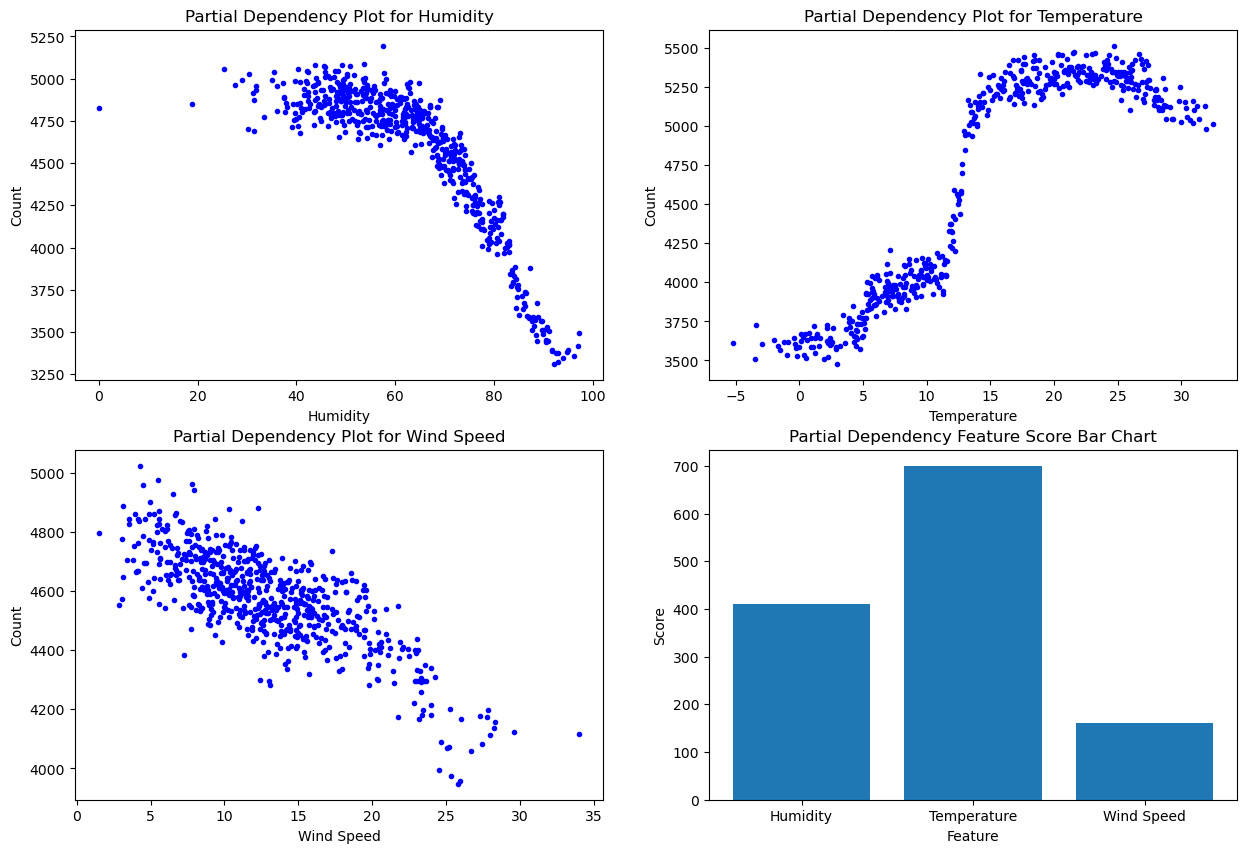

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pdp_data = PDPDataset('bikesharing_daily', drop_cols=['instant','dteday','casual','registered'])
pdp_model = PDPModel(model=RandomForestRegressor())
training_data_features = pdp_data.features_array(subset='train')
training_data_target = pdp_data.target_array(subset='train')
test_data_features = pdp_data.features_array(subset='test')
test_data_target = pdp_data.target_array(subset='test')
print()
print(f'Train Features: {training_data_features.shape}, Train Target: {training_data_target.shape}')
print(f'Test Features: {test_data_features.shape}, Test Target: {test_data_target.shape}')
test_score = pdp_model.train_and_test(training_data_features, training_data_target,
                                      test_data_features, test_data_target)

print()
print('Trained the Model on the Training Data. Test Score: ', test_score)

pdp = PartialDependencyPlot(pdp_data, pdp_model)
feature_labels = [('hum', 'Humidity'), ('temp', 'Temperature'), ('windspeed', 'Wind Speed')]
features, labels = zip(*feature_labels)
feature_scores = pdp.plot(features, sample_size=100, subset='test', labels=labels,
                          denorm_fns=[lambda x: (x * 100), lambda x: (x * 47 - 8), lambda x: (x * 67)])

Individual Conditional Expectation (ICE) for a datapoint $\mathbf{x}$ with respect to a feature $F$ for a model (to be interpreted) implicitly defining the function $f$
$$f_{ICE}(x_F^{(j)}) = f(x_F^{(j)},\mathbf{x}_{-F})$$
where $x_F^{(j)}$ is the j-th sample interpolated value for $x_F$, while keeping all other values ($\mathbf{x}_{-F}$) same.

In [ ]:
class ICE:
    def __init__(self, dataset:PDPDataset, model:PDPModel):
        self.dataset = dataset
        self.model = model

    def plot(self, datapoints:Array, features:List[str], sample_size:int=100,
             labels:List[str]=None, denorm_fns:List[Any]=None):
        assert set(features).issubset(set(self.dataset.all_features)), "Features must be a subset of dataset features."
        labels = labels if labels is not None else features
        denorm_fns = denorm_fns if denorm_fns is not None else [None] * len(features)
        # Generate the ICE plot for each of the features given
        plot_size = int(math.ceil(math.sqrt(len(features))))
        for i, (f, label, denorm_fn) in enumerate(zip(features, labels, denorm_fns)):
            f_index = self.dataset.all_features.index(f)
            # Get the interpolatd values for the feature and the augmented dataset using copies of 'datapoints'
            interpolated_f_values, ice_data = self.dataset.interpolated_data(datapoints, f, sample_size)
            augmented_size = ice_data.shape[0] * ice_data.shape[1]
            # Generate model predictions for all the generated datapoints
            aug_predictions = self.model.predict(ice_data.reshape(augmented_size, -1)).reshape(ice_data.shape[0], ice_data.shape[1])
            # Get the predictions for the original datapoints
            original_predictions = self.model.predict(datapoints)

            # Show the ICE plot
            # Show the positions of each of the original datapoints along with the predictions
            original_f_values = datapoints[:, f_index] if denorm_fn is None else denorm_fn(datapoints[:, f_index])

            plot_row, plot_col = divmod(i, plot_size)
            subplt = plt.subplot2grid((plot_size, plot_size), (plot_row, plot_col))
            subplt.scatter(original_f_values, original_predictions, marker='o', color='red')
            x_values = (interpolated_f_values if denorm_fn is None else denorm_fn(interpolated_f_values))
            for i in range(ice_data.shape[0]):
                # Plot a curve for each datapoint
                predictions = aug_predictions[i]
                subplt.plot(x_values, predictions, linestyle='-')
            subplt.set_xlabel(label)
            subplt.set_ylabel('Count')
            subplt.set_title(f'ICE Plot for {label}')
        plt.show()

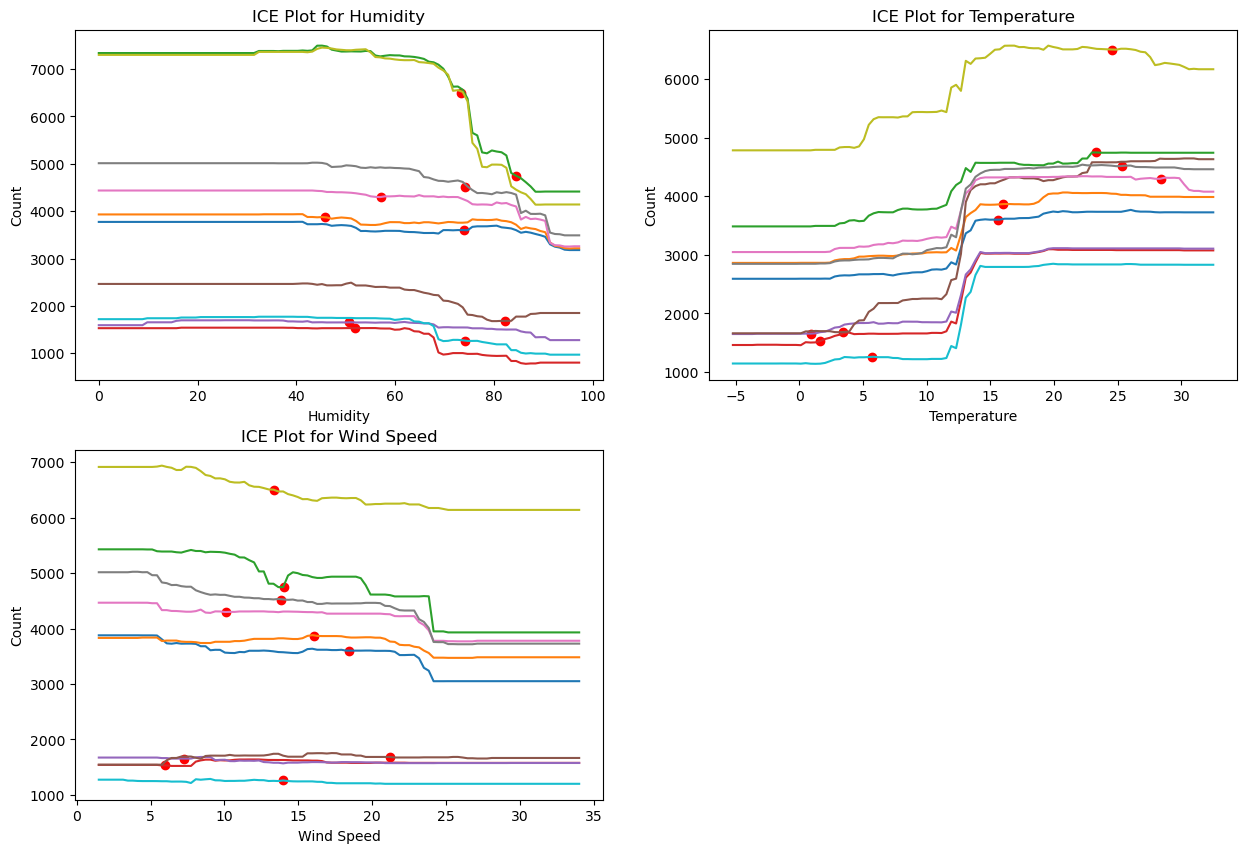

In [ ]:
ice = ICE(pdp_data, pdp_model)
ice.plot(ice.dataset.features_array(subset='test', sample_size=10),
         ['hum', 'temp', 'windspeed'], sample_size=100,
         labels=['Humidity', 'Temperature', 'Wind Speed'],
         denorm_fns=[lambda x: (x * 100), lambda x: (x * 47 - 8), lambda x: (x * 67)])

Permutation Feature Importance - given a trained model $f$, feature matrix $M$ with $n$ datapoints, target $\mathbf{y}$ and a loss function $L$, error by the model on the original dataset is given by
$$\epsilon = \frac{1}{n}\sum_{i=1}^n L(y^{(i)}, f(\mathbf{x}^{(i)}))$$
Assuming we carry out $m$ permutations of the values $(x^{(i)}_F, i=1,\ldots,n)$ across the datapoints for feature $F$, and denoting the value assigned to the feature $F$ for the i-th datapoint in the j-th permutation as $x_F^{(\pi_j(i))}$, the mean error $\epsilon_p$ incurred by the model on permutations is
$$\epsilon'_F = \frac{1}{m}\sum_{j=1}^m\left(\frac{1}{n}\sum_{i=1}^n L(y^{(i)}, f(x_F^{(\pi_j(i))}, \mathbf{x}_{-F}^{(i)}))\right)$$
The first summation is over all the $m$ permutations, and expression inside the paranthesis after the first summation is the error for the j-th permuted dataset. The PCI score for feature $F$ is then $$PFI_F = \frac{\epsilon'_F}{\epsilon}$$.
Higher the PFI score, more influence the feature has on the target.

In [ ]:
plt.rcParams["figure.figsize"] = (8,5)

class PFI:
    def __init__(self, dataset:PDPDataset, model:PDPModel):
        self.dataset = dataset
        self.model = model

    def plot(self, features:List[str], n_permutations:int=100,
             labels:List[str]=None):
        assert set(features).issubset(set(self.dataset.all_features)), "Features must be a subset of dataset features."
        labels = labels if labels is not None else features

        pfi_scores = []
        for f, label in zip(features, labels):
            # Augment the dataset with n_permutations of the original datapoint
            # each version has the values of feature 'f' permuted across the datapoints
            permuted_feature_values = self.dataset.permute_feature_values(f, n_permutations=n_permutations)
            # The +1 includes the original datapoints
            assert permuted_feature_values.shape == (self.dataset.size(), (n_permutations+1), self.dataset.dim)
            targets = self.dataset.target_array()
            # Compute the MSE loss for each of the permuted and the original datapoints
            losses = self.model.mse(permuted_feature_values, targets)
            assert losses.shape == (n_permutations+1,)
            # The first element is the loss for the original dataset and the rest are the losses for the permuted datasets
            original_error, permutation_error = losses[0], np.mean(losses[1:])
            # Get the 5% and 95% quantiles for the losses due to permutations
            # More important the feature more the variation in the loss among the permutations
            perm_q5_pfi, perm_q95_pft = tuple((np.quantile(losses[1:], [0.05, 0.95])/original_error).tolist())
            # Add the PFI score and the quantiles to the list of error values for the features
            mean_perm_pfi = permutation_error/original_error
            error_low, error_high = (mean_perm_pfi - perm_q5_pfi), (perm_q95_pft - mean_perm_pfi)
            pfi_scores.append((label, mean_perm_pfi, error_low, error_high))

        # Plot the PFI score bar chart
        labels, scores, low_errs, high_errs = zip(*pfi_scores)
        errs = [Array(low_errs), Array(high_errs)]
        plt.errorbar(labels, scores, yerr=errs, fmt='o')
        plt.xlabel('Feature')
        plt.ylabel('Score')
        plt.title(f'Permutation Feature Importance Score Bar Chart')
        plt.show()

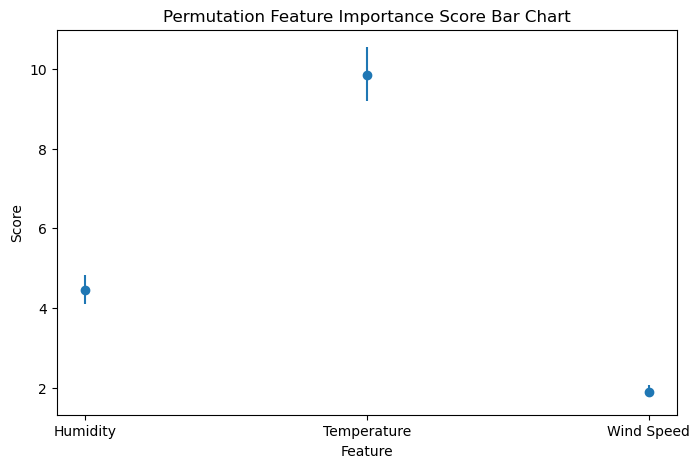

In [ ]:
pfi = PFI(pdp_data, pdp_model)
pfi.plot(features=['hum', 'temp', 'windspeed'],
         labels=['Humidity', 'Temperature', 'Wind Speed'],
         n_permutations=100)